In [1]:
import matplotlib
#%matplotlib notebook
%matplotlib widget

In [2]:
from matplotlib import pyplot as plt
from tifffile import TiffFile
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
#pth = Path('K:\\SurfDrive\\Screening_Data_Mutable\\2019\\12\\05\\')
pth = Path('C:\\Users\\thinkBookUser\\Desktop\\Screening_Data_Analyzed\\2019\\12\\05\\caged\\')
well = 'D03'
frameinterval = 2
meanfile = well+'_I_mean.tif'
lblfile = well+'_I_mean_labelmap.tif'
taufile = well+'_tau.csv'
fitfile = well+'_fit.csv'
errfile = well+'_errors.csv'

def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c))

def whaterror(error):
    errorlist = ["ROI does not excist",
                 "ROI smaller than min_pix",
                 "ROI mean intensity smaller than min_int",
                 "ROI intensitytrace has one or more zeros",
                 "Trace starts outside of the stabilityrange",
                 "Trace has NaNs",
                 "Trace gave a runtime error in the fit",
                 "Trace error on the rate is bigger than maxerror",
                 "Fit does not start around the start of the data"]
    errors = []
    for i in range(len(errorlist) + 1):
        if int(error) & (1 << i):
            errors.append(errorlist[i])
    return errors

In [4]:
mean_tf = TiffFile(Path(pth,'intensity_data',meanfile))
mean_im = mean_tf.asarray()

In [5]:
%matplotlib widget
#comment this out if matplotlib_notebook works for you
fig=plt.figure(figsize=(5,5))
plt.imshow(mean_im[0,:,:])
plt.title('note down coords in next cell, then click blue button')
# NB: if you use matplotlib_widget then there is no blue button, so just move inline before plotting

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Text(0.5, 1.0, 'note down coords in next cell, then click blue button')

ROI nr: 184


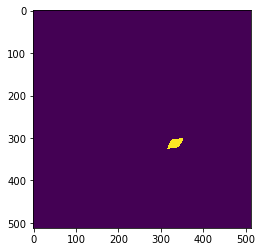

In [6]:
coords = (152,310) # x, y
lbl_tf = TiffFile(Path(pth,'intensity_data',lblfile))
lbl_im = lbl_tf.asarray()
roiNr = lbl_im[int(coords[1]),int(coords[0])]
print('ROI nr: '+str((roiNr)))
%matplotlib inline
#comment this out if matplotlib_notebook works for you
plt.imshow(lbl_im==(roiNr+1))
# you can also comment this line out if you dont want to see, which cell was selected

ROI nr: 184
No errors!


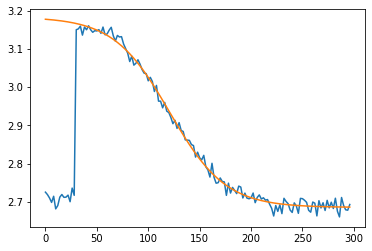

In [7]:
lifetimetraces = np.loadtxt(Path(pth,'results',taufile))
errors = np.loadtxt(Path(pth,'results',errfile))
fitvalues = pd.read_csv(Path(pth,'results',fitfile))

lifetimetrace = lifetimetraces[roiNr]
error = errors[roiNr]
fitvalue = fitvalues.iloc[roiNr]
%matplotlib inline
#comment this out if matplotlib_notebook works for you
xdat = np.arange(0, len(lifetimetrace) * frameinterval, frameinterval)
plt.plot(xdat,lifetimetrace)
plt.plot(xdat,fit_function(xdat, fitvalue['start(ns)'], fitvalue['range(ns)'], fitvalue['breakdown_time(s)'], fitvalue['midpoint(s)']))
#plt.title('Do not forget to click the blue button')
print('ROI nr: '+str((roiNr)))
if whaterror(error) == []:
    print ('No errors!')
else:
    print(whaterror(error))